# Ejemplo 1:Método de Elementos Finitos en 2D

Este notebook presenta una implementación simple del método de elementos finitos para resolver la ecuación de Poisson en 2D en un dominio cuadrado unitario. El notebook incluye inicialmente una malla simple 3x3 nodos con 9 elementos triangulares, que es suficiente para demostrar los conceptos básicos sin complicar demasiado el código. Luego modificamos el ejemplo par aumentar a 25 nodos defieniendo los triánguaos de forma manual. Finalmente el ejemplo es mejorado pr incluir una mala NXN donde la triangulación se hace usando la **rutina de Delanaury**. 

see:[ Material extra](https://users.metu.edu.tr/csert/me582/ME582%20Ch%2003.pdf)

## 1. Importación de Librerías

Importamos las librerías necesarias para cálculos numéricos, matrices sparse y visualización.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Configuración de matplotlib
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 6)

## 2. Definición del Problema

Resolveremos la ecuación de Poisson: $-\nabla^2 u(x,y) = f(x,y)$ en el dominio $[0,1] × [0,1]$ con condiciones de frontera de Dirichlet $u = 0$ en el borde.

Usaremos $f = 1$ para un ejemplo simple.

## 3. Generación de la Malla

Creamos una malla triangular simple dividiendo el cuadrado en dos triángulos.

Número de nodos: 9
Número de elementos: 8


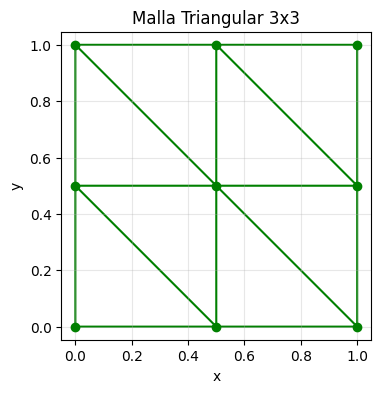

In [3]:
# Nodos de la malla (9 nodos en una cuadrícula 3x3)
x_coords = np.linspace(0, 1, 3)
y_coords = np.linspace(0, 1, 3)
X, Y = np.meshgrid(x_coords, y_coords)
nodes = np.column_stack((X.ravel(), Y.ravel()))
# Elementos (8 triángulos dividiendo cada cuadrado en 2)
elements = np.array([
    [0, 1, 3], [1, 4, 3],  # inferior izquierdo
    [1, 2, 4], [2, 5, 4],  # inferior derecho
    [3, 4, 6], [4, 7, 6],  # superior izquierdo
    [4, 5, 7], [5, 8, 7]   # superior derecho
])

# Número de nodos y elementos
n_nodes = len(nodes)
n_elements = len(elements)

print(f"Número de nodos: {n_nodes}")
print(f"Número de elementos: {n_elements}")

# Visualización de la malla
plt.figure(figsize=(4, 4))
plt.triplot(nodes[:, 0], nodes[:, 1], elements, 'go-')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Malla Triangular 3x3')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Funciones Base

Usaremos elementos triangulares lineales con funciones base:
- $φ₁(ξ,η) = N_3= 1 - ξ - η$
- $φ₂(ξ,η)=N_1 = ξ$
- $φ₃(ξ,η) = N_2 = η$

donde $(ξ,η)$ son coordenadas locales en el triángulo de referencia.

## 5. Ensamblaje de la Matriz de Rigidez

La matriz de rigidez elemental para un triángulo lineal es:
$$K_e = \frac{1}{4A} \begin{pmatrix} b_1^2 + c_1^2 & b_1 b_2 + c_1 c_2 & b_1 b_3 + c_1 c_3 \\ b_2 b_1 + c_2 c_1 & b_2^2 + c_2^2 & b_2 b_3 + c_2 c_3 \\ b_3 b_1 + c_3 c_1 & b_3 b_2 + c_3 c_2 & b_3^2 + c_3^2 \end{pmatrix}$$

donde $b_i, c_i$ son derivadas de las funciones de forma.

In [4]:
# Función para calcular el área de un triángulo
def triangle_area(nodes_elem):
    x1, y1 = nodes_elem[0]
    x2, y2 = nodes_elem[1]
    x3, y3 = nodes_elem[2]
    return 0.5 * abs((x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1))

# Función para calcular la matriz de rigidez elemental
def element_stiffness(nodes_elem):
    x1, y1 = nodes_elem[0]
    x2, y2 = nodes_elem[1]
    x3, y3 = nodes_elem[2]

    # Área
    A = triangle_area(nodes_elem)

    # Coeficientes b y c
    b1 = y2 - y3
    b2 = y3 - y1
    b3 = y1 - y2
    c1 = x3 - x2
    c2 = x1 - x3
    c3 = x2 - x1

    # Matriz de rigidez elemental
    Ke = np.array([
        [b1*b1 + c1*c1, b1*b2 + c1*c2, b1*b3 + c1*c3],
        [b2*b1 + c2*c1, b2*b2 + c2*c2, b2*b3 + c2*c3],
        [b3*b1 + c3*c1, b3*b2 + c3*c2, b3*b3 + c3*c3]
    ])/(4*A)

    return Ke

# Matriz de rigidez global (9X9)
K = lil_matrix((n_nodes, n_nodes))

# Ensamblaje
for elem in elements: # Elementos (8 triángulos dividiendo cada cuadrado en 2)
    nodes_elem = nodes[elem] # Nodos del elemento actual elem
    Ke = element_stiffness(nodes_elem) # Matriz de rigidez elemental para un elemento triangular
    for i in range(3):
        for j in range(3):
            K[elem[i], elem[j]] += Ke[i, j]

print("Matriz de rigidez global:")
print(K.toarray())

Matriz de rigidez global:
[[ 1.  -0.5  0.  -0.5  0.   0.   0.   0.   0. ]
 [-0.5  2.  -0.5  0.  -1.   0.   0.   0.   0. ]
 [ 0.  -0.5  1.   0.   0.  -0.5  0.   0.   0. ]
 [-0.5  0.   0.   2.  -1.   0.  -0.5  0.   0. ]
 [ 0.  -1.   0.  -1.   4.  -1.   0.  -1.   0. ]
 [ 0.   0.  -0.5  0.  -1.   2.   0.   0.  -0.5]
 [ 0.   0.   0.  -0.5  0.   0.   1.  -0.5  0. ]
 [ 0.   0.   0.   0.  -1.   0.  -0.5  2.  -0.5]
 [ 0.   0.   0.   0.   0.  -0.5  0.  -0.5  1. ]]


## 6. Ensamblaje del Vector de Carga

Para $f = 1$, el vector de carga elemental es:
$$b_i = \frac{A}{3} \begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix}$$

donde $A$ es el área del elemento.

In [5]:
# Vector de carga global
b = np.zeros(n_nodes)

# Ensamblaje del vector de carga
for elem in elements:
    nodes_elem = nodes[elem]
    A = triangle_area(nodes_elem)
    Fe = (A/3)*np.ones(3)  # f = 1
    for i in range(3):
        b[elem[i]] += Fe[i]

print("Vector de carga global:")
print(b)

Vector de carga global:
[0.04166667 0.125      0.08333333 0.125      0.25       0.125
 0.08333333 0.125      0.04166667]


## 7. Aplicación de Condiciones de Frontera

Aplicamos condiciones de Dirichlet $u = 0$ en todos los nodos del borde (todos los nodos en este caso).

In [6]:
# Nodos del borde
boundary_nodes = []
for i, (x, y) in enumerate(nodes):
    if x == 0 or x == 1 or y == 0 or y == 1:
        boundary_nodes.append(i)

print(f"Nodos del borde: {boundary_nodes}")

# Aplicar condiciones de frontera Dirichlet u=0 en nodos del borde
for i in boundary_nodes:
    K[i, :] = 0
    K[i, i] = 1
    b[i] = 0

print("Sistema después de aplicar BC:")
print("K:")
print(K.toarray())
print("b:")
print(b)

Nodos del borde: [0, 1, 2, 3, 5, 6, 7, 8]
Sistema después de aplicar BC:
K:
[[ 1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0. -1.  0. -1.  4. -1.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1.]]
b:
[0.   0.   0.   0.   0.25 0.   0.   0.   0.  ]


## 8. Resolución del Sistema

Resolvemos el sistema lineal $Au = b$ para obtener la solución aproximada.

In [7]:
# Resolver el sistema. Solve the sparse linear system Ax=b, where b may be a vector or a matrix.
u = spsolve(K.tocsr(), b)

print("Solución u en cada nodo:")
for i, val in enumerate(u):
    print(f"Nodo {i} ({nodes[i][0]:.1f}, {nodes[i][1]:.1f}): u = {val:.4f}")

Solución u en cada nodo:
Nodo 0 (0.0, 0.0): u = 0.0000
Nodo 1 (0.5, 0.0): u = 0.0000
Nodo 2 (1.0, 0.0): u = 0.0000
Nodo 3 (0.0, 0.5): u = 0.0000
Nodo 4 (0.5, 0.5): u = 0.0625
Nodo 5 (1.0, 0.5): u = 0.0000
Nodo 6 (0.0, 1.0): u = 0.0000
Nodo 7 (0.5, 1.0): u = 0.0000
Nodo 8 (1.0, 1.0): u = 0.0000


In [7]:
u

array([0.    , 0.    , 0.    , 0.    , 0.0625, 0.    , 0.    , 0.    ,
       0.    ])

## 9. Visualización de Resultados

Visualizamos la solución aproximada usando una interpolación triangular.

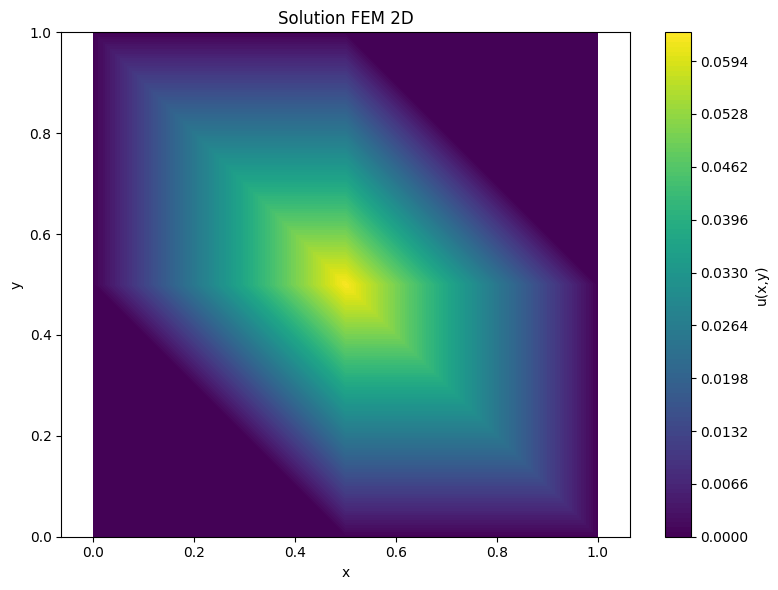

Valor máximo de u: 0.0625
Valor en el centro: 0.0625


In [8]:
# Visualización
plt.figure(figsize=(8, 6))

# Gráfico de contornos
plt.tricontourf(nodes[:, 0], nodes[:, 1], elements, u, levels=120, cmap='viridis')
plt.colorbar(label='u(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Solution FEM 2D')
plt.axis('equal')

plt.tight_layout()
plt.show()

print(f"Valor máximo de u: {np.max(u):.4f}")
print(f"Valor en el centro: {u[4]:.4f}")  # Nodo central

In last plot we can see the signal propagation and the original triangular grid

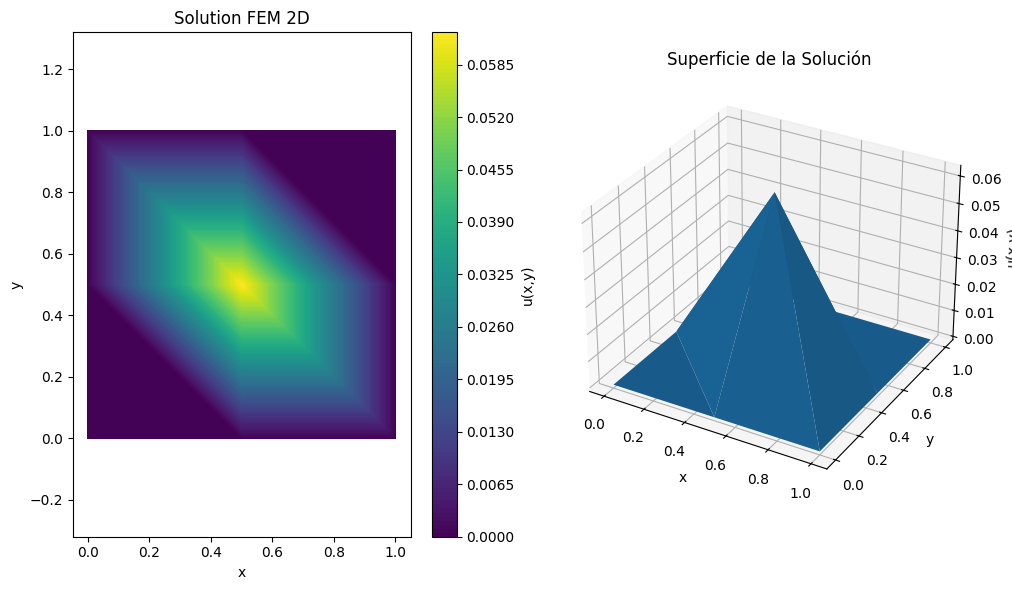

Valor máximo de u: 0.0625
Valor en el centro: 0.0625


In [8]:
# Visualización
plt.figure(figsize=(10, 6))

# Gráfico de contornos
plt.subplot(1, 2, 1)
plt.tricontourf(nodes[:, 0], nodes[:, 1], elements, u, levels=150, cmap='viridis')
plt.colorbar(label='u(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Solution FEM 2D')
plt.ylim(0.0, 1.0)
plt.axis('equal')

# Gráfico 3D
ax = plt.subplot(1, 2, 2, projection='3d')
ax.plot_trisurf(nodes[:, 0], nodes[:, 1], u, triangles=elements,  edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')
ax.set_title('Superficie de la Solución')

plt.tight_layout()
plt.show()

print(f"Valor máximo de u: {np.max(u):.4f}")
print(f"Valor en el centro: {u[4]:.4f}")  # Nodo central

## Conclusión

Este notebook demostró una implementación básica del método de elementos finitos en 2D usando elementos triangulares lineales. La solución obtenida es una aproximación por partes lineal que satisface las condiciones de frontera.

Para problemas más complejos, se pueden usar:
- Mallados más finos
- Elementos de orden superior
- Librerías especializadas como FEniCS

**Ejercicio de laboratorio**: 
* Mofica el código anterior para un enmallado más fino.
* Modifica el código para resolver la ecuación de Poisson con una función de fuente no constante, por ejemplo, f(x,y) = sin(pi*x)*sin(pi*y). Asegúrate de actualizar el ensamblaje del vector de carga F para reflejar esta nueva función de fuente. Visualiza la solución resultante y compara con la solución analítica si es posible.

# Ejemplo 2: Método de Elementos Finitos en 2D

El notebook incluye una malla mejorada  5x5 con elementos triangulares para resolver la ecuación de Poisson en 2D en un dominio cuadrado unitario.


Número de nodos: 25
Número de elementos: 32


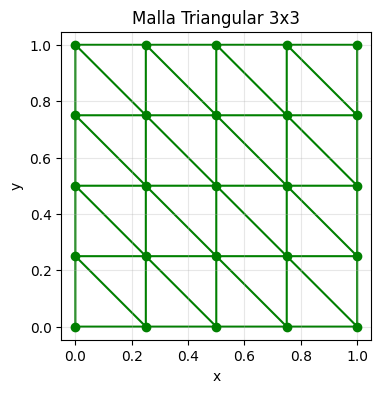

In [9]:
# Nodos de la malla (25 nodos en una cuadrícula )
x_coords = np.linspace(0, 1, 5)
y_coords = np.linspace(0, 1, 5)
X, Y = np.meshgrid(x_coords, y_coords)
nodes = np.column_stack((X.ravel(), Y.ravel()))
# Elementos (32 triángulos dividiendo cada cuadrado en 5)
elements = np.array([
    [0, 1, 5], [1, 6, 5], [1,2,6], [2,7,6], [2,3,7], [3,8,7], [3,4,8], [4,9,8], 
    [5,6,10], [6,11,10], [6,7,11],[7,12,11], [7,8,12],[8,13,12], [8,9,13], [9,14,13],
    [10,11,15],[11,16,15],[11,12,16],[12,17,16],[12,13,17],[13,18,17], [13,14,18],[14,19,18],
    [15,16,20],[16,21,20],[16,17,21],[17,22,21], [17,18,22],[18,23,22],[18,19,23],[19,24,23]
])

# Número de nodos y elementos
n_nodes = len(nodes)
n_elements = len(elements)

print(f"Número de nodos: {n_nodes}")
print(f"Número de elementos: {n_elements}")

# Visualización de la malla
plt.figure(figsize=(4, 4))
plt.triplot(nodes[:, 0], nodes[:, 1], elements, 'go-')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Malla Triangular 3x3')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

Notice that we did a symmetrical triangulation

Nodos del borde: [0, 1, 2, 3, 4, 5, 9, 10, 14, 15, 19, 20, 21, 22, 23, 24]


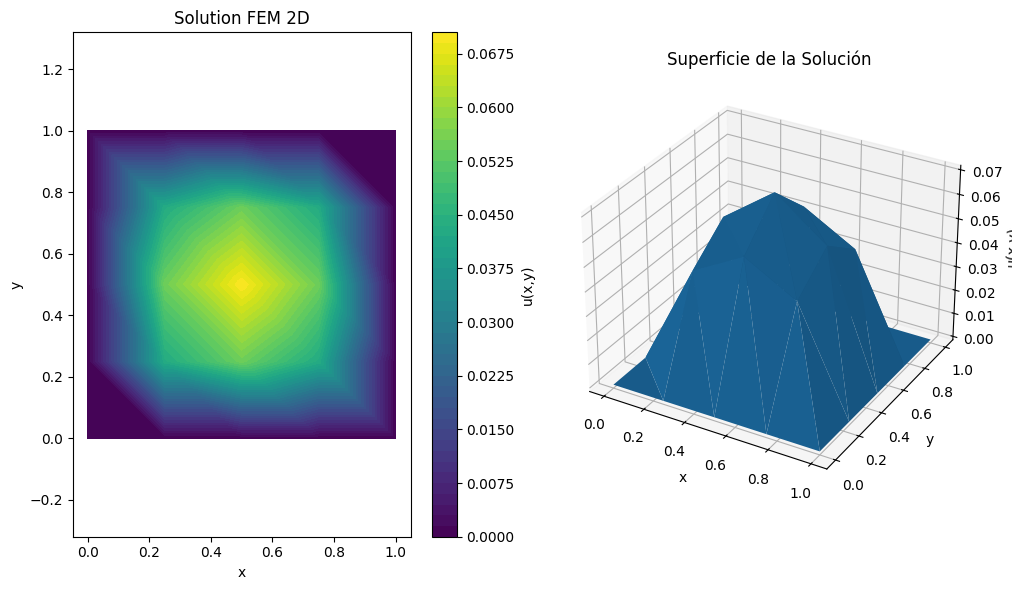

Valor máximo de u: 0.0703
Valor en el centro: 0.0000


In [ ]:
# Matriz de rigidez global (5X5)
K = lil_matrix((n_nodes, n_nodes))

# Ensamblaje
for elem in elements: # Elementos (32 triángulos)
    nodes_elem = nodes[elem] # Nodos del elemento actual elem
    Ke = element_stiffness(nodes_elem) # Matriz de rigidez elemental para un elemento triangular
    for i in range(3):
        for j in range(3):
            K[elem[i], elem[j]] += Ke[i, j]

#print("Matriz de rigidez global:")
#print(K.toarray())


# Vector de carga global
b = np.zeros(n_nodes)

# Ensamblaje del vector de carga
for elem in elements:
    nodes_elem = nodes[elem]
    A = triangle_area(nodes_elem)
    Fe = (A/3)*np.ones(3)  # f = 1
    for i in range(3):
        b[elem[i]] += Fe[i]

#print("Vector de carga global:")
#print(b)

# Nodos del borde
boundary_nodes = []
for i, (x, y) in enumerate(nodes):
    if x == 0 or x == 1 or y == 0 or y == 1:
        boundary_nodes.append(i)

print(f"Nodos del borde: {boundary_nodes}")

# Aplicar condiciones de frontera Dirichlet u=0 en nodos del borde
for i in boundary_nodes:
    K[i, :] = 0
    K[i, i] = 1
    b[i] = 0

'''
print("Sistema después de aplicar BC:")
print("K:")
print(K.toarray())
print("b:")
print(b)
'''

# Resolver el sistema. Solve the sparse linear system Ax=b, where b may be a vector or a matrix.
u = spsolve(K.tocsr(), b)

'''print("Solución u en cada nodo:")
for i, val in enumerate(u):
    print(f"Nodo {i} ({nodes[i][0]:.1f}, {nodes[i][1]:.1f}): u = {val:.4f}")'''

# Visualización
plt.figure(figsize=(10, 6))

# Gráfico de contornos
plt.subplot(1, 2, 1)
plt.tricontourf(nodes[:, 0], nodes[:, 1], elements, u, levels=50, cmap='viridis')
plt.colorbar(label='u(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Solution FEM 2D')
plt.ylim(0.0, 1.0)
plt.axis('equal')

# Gráfico 3D
ax = plt.subplot(1, 2, 2, projection='3d')
ax.plot_trisurf(nodes[:, 0], nodes[:, 1], u, triangles=elements,  edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')
ax.set_title('Superficie de la Solución')

plt.tight_layout()
plt.show()

print(f"Valor máximo de u: {np.max(u):.4f}")
print(f"Valor en el centro: {u[4]:.4f}")  # Nodo central

Notice that our solution is much better. The field increase to ~ 0.07 at center.

---

# Example 3: Using Delanaury


Solve the same problem using Delanaury algoritm for the triangulation (no symmetrical case)

Número de nodos: 25
Número de elementos: 32


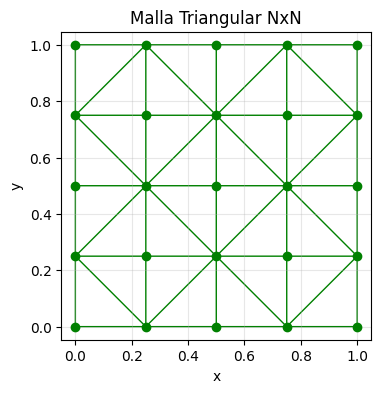

In [31]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# Nodos de la malla (25 nodos en una cuadrícula with 32 elements)
N = 5
x_coords = np.linspace(0, 1, N)
y_coords = np.linspace(0, 1, N)
X, Y = np.meshgrid(x_coords, y_coords)
#plt.plot(X,Y,'b.')
nodes = np.column_stack((X.ravel(), Y.ravel()))

elements = tri.Triangulation(X.ravel(), Y.ravel())

# Número de nodos y elementos
n_nodes = len(nodes)
n_elements = len(elements.triangles)

print(f"Número de nodos: {n_nodes}")
print(f"Número de elementos: {n_elements}")

# Visualización de la malla
plt.figure(figsize=(4, 4))
plt.triplot(elements, 'go-', lw=1)
#plt.triplot(nodes[:, 0], nodes[:, 1], elements, 'go-')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Malla Triangular NxN')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

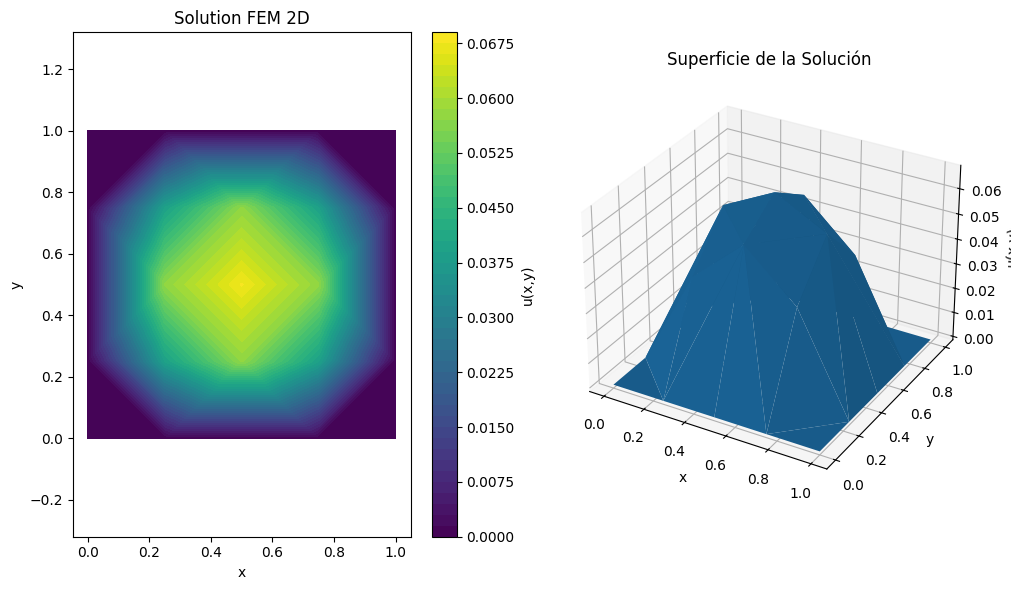

Valor máximo de u: 0.0677
Valor en el centro: 0.0000


In [ ]:
# Matriz de rigidez global (NXN)
K = lil_matrix((n_nodes, n_nodes))

# Ensamblaje
for elem in elements.triangles: # Elementos (32 triángulos)
    nodes_elem = nodes[elem] # Nodos del elemento actual elem
    Ke = element_stiffness(nodes_elem) # Matriz de rigidez elemental para un elemento triangular
    for i in range(3):
        for j in range(3):
            K[elem[i], elem[j]] += Ke[i, j]

#print("Matriz de rigidez global:")
#print(K.toarray())


# Vector de carga global
b = np.zeros(n_nodes)

# Ensamblaje del vector de carga
for elem in elements.triangles:
    nodes_elem = nodes[elem]
    A = triangle_area(nodes_elem)
    Fe = (A/3)*np.ones(3)  # f = 1
    for i in range(3):
        b[elem[i]] += Fe[i]

#print("Vector de carga global:")
#print(b)

# Nodos del borde
boundary_nodes = []
for i, (x, y) in enumerate(nodes):
    if x == 0 or x == 1 or y == 0 or y == 1:
        boundary_nodes.append(i)

#print(f"Nodos del borde: {boundary_nodes}")

# Aplicar condiciones de frontera Dirichlet u=0 en nodos del borde
for i in boundary_nodes:
    K[i, :] = 0
    K[i, i] = 1
    b[i] = 0

# Resolver el sistema. Solve the sparse linear system Ax=b, where b may be a vector or a matrix.
u = spsolve(K.tocsr(), b)

# Visualización
plt.figure(figsize=(10, 6))

# Gráfico de contornos
plt.subplot(1, 2, 1)
plt.tricontourf(nodes[:, 0], nodes[:, 1], elements.triangles, u, levels=50, cmap='viridis')
plt.colorbar(label='u(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Solution FEM 2D')
plt.ylim(0.0, 1.0)
plt.axis('equal')

# Gráfico 3D
ax = plt.subplot(1, 2, 2, projection='3d')
ax.plot_trisurf(nodes[:, 0], nodes[:, 1], u, triangles=elements.triangles,  edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')
ax.set_title('Superficie de la Solución')

plt.tight_layout()
plt.show()

print(f"Valor máximo de u: {np.max(u):.4f}")
print(f"Valor en el centro: {u[4]:.4f}")  # Nodo central

---
### Extra in the notebook

* sparse matix: The lil_matrix (List of Lists) is a SciPy sparse matrix format optimized for constructing matrices incrementally and flexible slicing...
* Esta es una estructura para construir matrices dispersas de forma incremental. Tenga en cuenta que insertar un solo elemento puede tomar tiempo lineal en el peor de los casos;

sparse matrix

In [15]:
import numpy as np
from scipy.sparse import lil_matrix

# 1. Initialize a 4x5 empty matrix with float64 data type
mtx = lil_matrix((4, 5), dtype=np.float64)

# 2. Assign values incrementally using standard NumPy-like indexing
mtx[0, 2] = 3.0
mtx[1, 3] = 7.5
mtx[3, 1] = 2.0

# 3. Use slicing to assign multiple values at once
mtx[2, 0:3] = [1.0, 4.0, 9.0]

# 4. View the internal "List of Lists" structure
# 'rows' stores column indices; 'data' stores the corresponding values
print("Row indices:", mtx.rows)
print("Data values:", mtx.data)

# 5. Convert to a dense NumPy array to see the full matrix
print("\nDense representation:\n", mtx.toarray())

Row indices: [list([2]) list([3]) list([0, 1, 2]) list([1])]
Data values: [list([np.float64(3.0)]) list([np.float64(7.5)]) list([1.0, 4.0, 9.0])
 list([np.float64(2.0)])]

Dense representation:
 [[0.  0.  3.  0.  0. ]
 [0.  0.  0.  7.5 0. ]
 [1.  4.  9.  0.  0. ]
 [0.  2.  0.  0.  0. ]]
